# Sub-256 crossover refinement

## tl;dr

This preregistered refinement narrows the best-case regular-kernel crossover
between 8 and 256 agents on a local GTX 1660 Ti and an ephemeral Modal L4.
All 864 timed observations completed successfully and passed the strict final
action/state/budget check.

- A resident one-step L4 transition first beats the faster compiled CPU at
  **16 agents** (median speedup 1.053×; descriptive bootstrap interval
  1.043–1.064×) and remains above it through 256.
- The GTX 1660 Ti one-step path does **not** cross by 256; its best measured
  point is 0.978× and the bootstrap interval spans 1.
- A single compiled 64-transition rollout crosses at the smallest tested
  population, **8 agents**, on both GPUs—even when final actions are copied to
  host after the rollout.

The result is not that GPU cores are cheap general-purpose CPU cores. It is
that a resident, shape-stable transition graph can amortize launch cost at a
surprisingly small cohort, especially when temporal work is fused.

## Design and interpretation

The workload fixes `W=8` float32 state values and `A=1` action state, then
varies population `N ∈ {8,16,32,64,128,256}` and observation horizon
`H ∈ {1,64}`. Each timed repetition executes 64 total transitions. `H=1`
therefore invokes the compiled graph 64 times; `H=64` invokes one graph that
contains all 64 transitions. Resident GPU state remains on device. Host-visible
mode copies final actions after each invocation.

Nine timed repetitions follow five warmups. The primary comparator is the
faster median of one- and eight-thread compiled CPU execution at each shape.
The crossover is the smallest tested population with GPU median wall time
below that tuned CPU median, exactly as frozen in
`preregistration/pilot-005.md`. Bootstrap intervals are descriptive ratios of
independently resampled cell medians; repetitions are not independent tasks
because each cell evolves persistent state.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data/processed"
FIGURE_DIR = ROOT / "results/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cells = pd.read_csv(PROCESSED_DIR / "sub256-cell-summary.csv")
speedups = pd.read_csv(PROCESSED_DIR / "sub256-speedups.csv")
crossovers = pd.read_csv(PROCESSED_DIR / "sub256-crossovers.csv")
shape_quality = pd.read_csv(PROCESSED_DIR / "sub256-shape-quality.csv")
run_quality = pd.read_csv(PROCESSED_DIR / "sub256-run-quality.csv")
host_penalty = pd.read_csv(PROCESSED_DIR / "sub256-host-penalty.csv")
fusion = pd.read_csv(PROCESSED_DIR / "sub256-temporal-fusion.csv")
manifest = json.loads((PROCESSED_DIR / "sub256-analysis-manifest.json").read_text())

sns.set_theme(style="whitegrid", context="notebook")
HARDWARE_ORDER = ["NVIDIA GeForce GTX 1660 Ti", "NVIDIA L4"]
MODE_STYLE = {
    "compiled-gpu-resident": {
        "label": "resident",
        "color": "#0B6E75",
        "marker": "o",
        "linestyle": "-",
    },
    "compiled-gpu-host-visible": {
        "label": "host-visible",
        "color": "#D97706",
        "marker": "s",
        "linestyle": "--",
    },
}

len(cells), len(speedups), len(crossovers), manifest["hypotheses"]

(96,
 48,
 8,
 {'S1_resident_h64_crosses_by_n128_on_both_gpus': True,
  'S2_l4_resident_h1_crosses_by_n256': True,
  'S3_host_visible_crossover_is_never_smaller': True,
  'S4_h64_proportional_fusion_advantage_gt_1_at_every_population': True,
  'observed_gtx_resident_h1_crossover': None})

## Data quality

In [2]:
assert (run_quality["rows"] == 432).all()
assert (run_quality["cases"] == 48).all()
assert (run_quality["execution_error_rows"] == 0).all()
assert (run_quality["duplicate_case_repetitions"] == 0).all()
assert (run_quality["invalid_shapes"] == 0).all()
assert set(cells["observations"]) == {9}
assert shape_quality["shape_valid"].all()
assert all(manifest["hypotheses"][key] for key in [
    "S1_resident_h64_crosses_by_n128_on_both_gpus",
    "S2_l4_resident_h1_crosses_by_n256",
    "S3_host_visible_crossover_is_never_smaller",
    "S4_h64_proportional_fusion_advantage_gt_1_at_every_population",
])

run_quality[
    [
        "hardware",
        "rows",
        "cases",
        "shapes",
        "invalid_shapes",
        "median_cell_cv",
        "p90_cell_cv",
        "cells_cv_over_10pct",
    ]
]

,hardware,rows,cases,shapes,invalid_shapes,median_cell_cv,p90_cell_cv,cells_cv_over_10pct
0,NVIDIA GeForce GTX 1660 Ti,432,48,12,0,0.015590,0.080244,3
1,NVIDIA L4,432,48,12,0,0.027698,0.082510,2


No observation is removed. Median within-cell CV is 1.56% on the GTX run and
2.77% on the L4 run; five of 96 cells exceed 10% CV and remain visible in the
processed ledger. Every shape passes strict correctness, avoiding the
branch-threshold divergence seen in the broader `A=8` atlas.

## Result: the small-cohort frontier

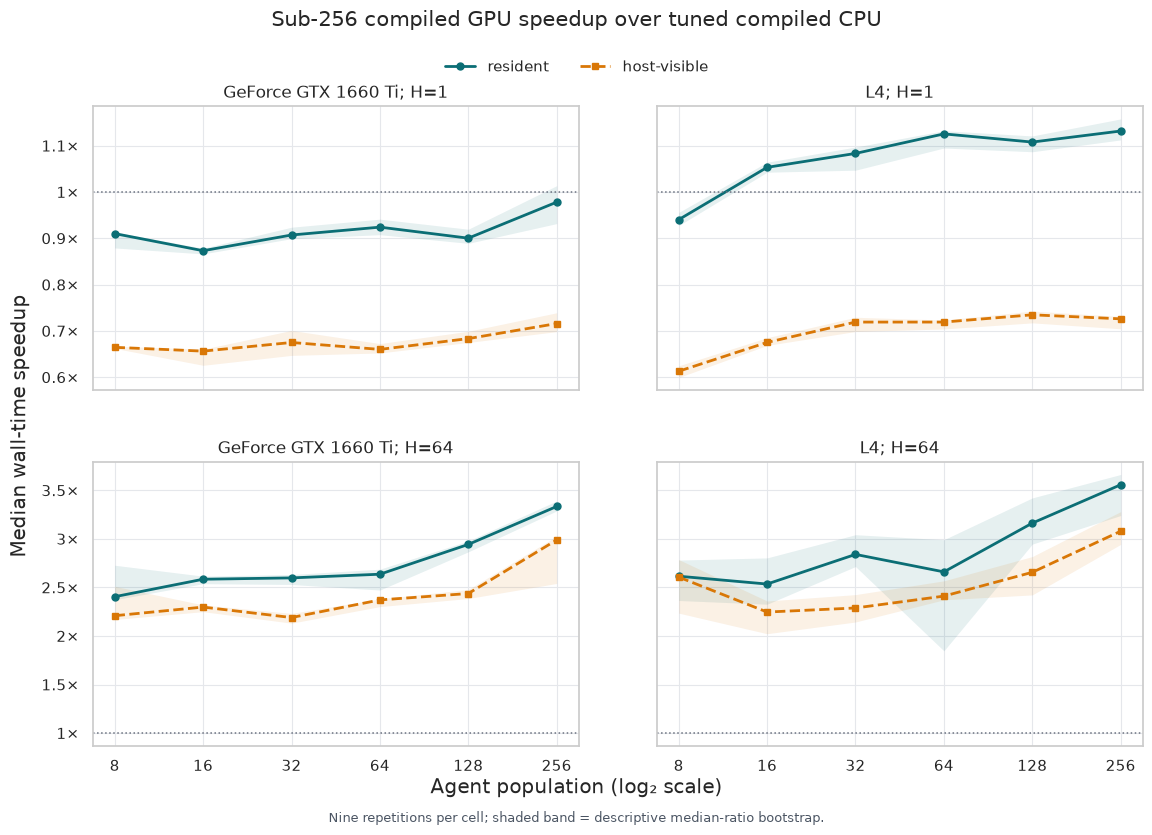

In [3]:
def speedup_label(value, _position):
    return f"{value:g}×"


fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.0), sharex=True, sharey="row")
for row_index, horizon in enumerate([1, 64]):
    for column_index, hardware in enumerate(HARDWARE_ORDER):
        axis = axes[row_index, column_index]
        panel = speedups[
            speedups["hardware"].eq(hardware)
            & speedups["observation_horizon"].eq(horizon)
            & speedups["shape_valid"]
        ]
        for mode, style in MODE_STYLE.items():
            series = panel[panel["mode"].eq(mode)].sort_values("agent_count")
            axis.plot(
                series["agent_count"],
                series["speedup_vs_best_cpu"],
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=2.0,
                markersize=5,
                label=style["label"],
            )
            axis.fill_between(
                series["agent_count"],
                series["speedup_vs_best_cpu_bootstrap_ci_low"],
                series["speedup_vs_best_cpu_bootstrap_ci_high"],
                color=style["color"],
                alpha=0.10,
                linewidth=0,
            )
        axis.axhline(1.0, color="#6B7280", linewidth=1.1, linestyle=":")
        axis.set_xscale("log", base=2)
        axis.set_xticks([8, 16, 32, 64, 128, 256])
        axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _pos: f"{value:g}"))
        axis.yaxis.set_major_formatter(FuncFormatter(speedup_label))
        axis.set_title(f"{hardware.replace('NVIDIA ', '')}; H={horizon}")
        axis.grid(True, which="major", color="#E5E7EB", linewidth=0.8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.975))
fig.suptitle("Sub-256 compiled GPU speedup over tuned compiled CPU", y=1.02, fontsize=15)
fig.supxlabel("Agent population (log₂ scale)", y=0.035)
fig.supylabel("Median wall-time speedup", x=0.02)
fig.text(
    0.5,
    0.005,
    "Nine repetitions per cell; shaded band = descriptive median-ratio bootstrap.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.subplots_adjust(left=0.09, right=0.98, bottom=0.10, top=0.90, hspace=0.25, wspace=0.16)
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURE_DIR / f"sub256-speedup-frontier.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

In [4]:
crossovers[
    [
        "hardware",
        "observation_horizon",
        "mode",
        "smallest_tested_crossover_n_best_cpu",
        "smallest_tested_ci_supported_crossover_n_best_cpu",
        "smallest_sustained_crossover_n_best_cpu",
        "max_valid_speedup_best_cpu",
    ]
]

,hardware,observation_horizon,mode,smallest_tested_crossover_n_best_cpu,smallest_tested_ci_supported_crossover_n_best_cpu,smallest_sustained_crossover_n_best_cpu,max_valid_speedup_best_cpu
0,NVIDIA GeForce GTX 1660 Ti,1,compiled-gpu-host-visible,NaN,NaN,NaN,0.715836
1,NVIDIA GeForce GTX 1660 Ti,1,compiled-gpu-resident,NaN,NaN,NaN,0.978048
2,NVIDIA GeForce GTX 1660 Ti,64,compiled-gpu-host-visible,8.0,8.0,8.0,2.988909
3,NVIDIA GeForce GTX 1660 Ti,64,compiled-gpu-resident,8.0,8.0,8.0,3.333715
4,NVIDIA L4,1,compiled-gpu-host-visible,NaN,NaN,NaN,0.734726
5,NVIDIA L4,1,compiled-gpu-resident,16.0,16.0,16.0,1.131651
6,NVIDIA L4,64,compiled-gpu-host-visible,8.0,8.0,8.0,3.078853
7,NVIDIA L4,64,compiled-gpu-resident,8.0,8.0,8.0,3.557256


The L4 `H=1` result is not a single isolated win: 16 is also the sustained
threshold, and the descriptive interval is above one there. Host visibility
prevents `H=1` from crossing anywhere in the tested range. On the GTX, even
resident `H=1` remains below the tuned CPU at 256. In contrast, whole-rollout
fusion places all four `H=64` hardware/visibility curves above one at `N=8`.
The true fused crossover is therefore at or below 8, not identified exactly.

## Residency and temporal fusion

In [5]:
host_penalty_summary = host_penalty.groupby(
    ["hardware", "observation_horizon"]
)["host_visibility_penalty"].agg(["min", "median", "max"])
host_penalty_summary

min    median       max
hardware                   observation_horizon                              
NVIDIA GeForce GTX 1660 Ti 1                    1.317389  1.355103  1.399987
                           64                   1.088657  1.120089  1.207477
NVIDIA L4                  1                    1.506524  1.546425  1.565107
                           64                   1.003466  1.141907  1.241124

In [6]:
fusion_summary = fusion.groupby(["hardware", "mode"])[
    "gpu_proportional_fusion_advantage"
].agg(["min", "median", "max"])
fusion_summary

min    median  \
hardware                   mode                                            
NVIDIA GeForce GTX 1660 Ti compiled-gpu-host-visible  3.244266  3.533555   
                           compiled-gpu-resident      2.641597  2.911933   
NVIDIA L4                  compiled-gpu-host-visible  3.182370  3.483276   
                           compiled-gpu-resident      2.363466  2.701707   

                                                           max  
hardware                   mode                                 
NVIDIA GeForce GTX 1660 Ti compiled-gpu-host-visible  4.175413  
                           compiled-gpu-resident      3.408541  
NVIDIA L4                  compiled-gpu-host-visible  4.252882  
                           compiled-gpu-resident      3.143421

Copying final actions after every one-step invocation costs a median 1.36× on
the GTX and 1.55× on L4. Fusing 64 transitions reduces the median penalty to
1.12× and 1.14×, respectively. At every tested population and in both
visibility modes, `H=64` improves GPU time proportionally more than it improves
the tuned CPU: the advantage ranges from 2.36× to 4.25×. This is the strongest
mechanistic evidence in the refinement—launch and observation frequency, not
just arithmetic volume, move the boundary.

## Cold compilation

In [7]:
compile_cells = cells.assign(
    backend=np.where(cells["mode"].eq("compiled-cpu"), "cpu", "cuda")
)
compile_cells.groupby(["hardware", "backend", "observation_horizon"])[
    "compile_first_call_ms"
].agg(["min", "median", "max"])

min  \
hardware                   backend observation_horizon                 
NVIDIA GeForce GTX 1660 Ti cpu     1                      649.335607   
                                   64                   12686.224817   
                           cuda    1                      352.920329   
                                   64                    8605.713128   
NVIDIA L4                  cpu     1                     1697.978501   
                                   64                   28694.528502   
                           cuda    1                     1413.507020   
                                   64                   21265.257878   

                                                              median  \
hardware                   backend observation_horizon                 
NVIDIA GeForce GTX 1660 Ti cpu     1                      670.123099   
                                   64                   13191.317768   
                           cuda    1                      540.029834   
                                   64                    9100.501329   
NVIDIA L4                  cpu     1                     1727.659922   
                                   64                   28875.737436   
                           cuda    1                     1767.417119   
                                   64                   22541.082850   

                                                                 max  
hardware                   backend observation_horizon                
NVIDIA GeForce GTX 1660 Ti cpu     1                     4821.256197  
                                   64                   13677.712899  
                           cuda    1                      633.468365  
                                   64                    9859.352842  
NVIDIA L4                  cpu     1                    27104.390687  
                                   64                   29241.359431  
                           cuda    1                     2181.498048  
                                   64                   23696.372313

Absolute first-call compilation is substantial: roughly 0.35–4.82 seconds for
the local one-step graphs, 1.41–27.10 seconds for L4 one-step graphs, and
8.61–29.24 seconds for 64-step graphs. Differential GPU-versus-CPU compile
cost is often zero because CUDA compilation happened to be faster in these
cells, but that does not make the cold start disappear. The steady-state
crossover applies to long-lived, reused shapes; short-lived ephemeral swarms
need compilation caching or ahead-of-time artifacts.

## Takeaways and limits

1. **The hardware threshold can be tiny in the regular regime.** On L4, a
   resident one-step graph crosses at 16 agents; a fused rollout crosses at or
   below 8 on both GPUs.
2. **Residency is necessary for the one-step L4 win.** Host-visible one-step
   execution never crosses by 256 on either GPU.
3. **Temporal fusion is the dominant lever.** It moves the GTX from no
   one-step win by 256 to a greater-than-2.4× fused win at 8.
4. **This does not establish an optimized CPU hardware ceiling.** The CPU
   comparator is matched PyTorch compilation on two particular cloud/local
   hosts, and the Modal CPU model string is masked. Confirmatory work needs
   C++/OpenMP/SIMD baselines and explicit CPU allocation metadata.
5. **A hardware crossover is only useful if the runtime can assemble a ready,
   same-route cohort.** The trace replay shows that exact-route heterogeneity
   can reduce eligibility to zero even when pooled load appears sufficient.
6. **The paper-level object is therefore three-dimensional:** readiness ×
   regularity × residency. The next intervention should lower route
   fragmentation (state bucketing or kernel fusion) and measure end-to-end
   queueing, cost, energy, and task utility.